# Pipeline de inferencia (`run_inference_batch`)

Este cuaderno ejecuta el flujo de inferencia del paquete **pia**: ResNet-18 CIFAR-10, `DataLoader` de test y `pia.inference.predict.run_inference_batch` (forward en eval, latencia y entropía en log).

**Ruta del código:** se añade `src/` al `sys.path` para poder hacer `import pia`.

**Salida:** métricas por batch (`df`) y, para el **primer batch** de test, una tabla por imagen con `ground_truth`, `prediction` y si acertó (`df_samples`). Tras cargar el modelo se imprime el **tamaño en memoria** (parámetros + buffers). La última celda **libera** modelo, loader y tablas, hace `gc.collect()` y `empty_cache` en CUDA/MPS.

In [7]:
"""Rutas del repositorio, hiperparámetros del cuaderno y opcional checkpoint."""

from __future__ import annotations

import logging
import sys
from pathlib import Path

import torch


def resolve_repo_root() -> Path:
    """Sube desde notebooks/ hasta la raíz del repo (directorio con src/pia)."""
    p = Path.cwd().resolve()
    if (p / "src" / "pia").is_dir():
        return p
    if (p.parent / "src" / "pia").is_dir():
        return p.parent
    msg = f"No se encontró src/pia. cwd={p}"
    raise FileNotFoundError(msg)


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

DATA_ROOT = str(REPO_ROOT / "data")
BATCH_SIZE = 128
MAX_BATCHES = 20
# Pesos finales del run IMP en runs/lt/large-checkpoint/ (state_dict en CPU).
STATE_DICT_PATH: Path | None = REPO_ROOT / "runs" / "lt" / "large-checkpoint" / "model_final.pt"
# Sin checkpoint entrenado: STATE_DICT_PATH = None

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("STATE_DICT_PATH:", STATE_DICT_PATH)

REPO_ROOT: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia
DATA_ROOT: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia/data
STATE_DICT_PATH: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia/runs/lt/large-checkpoint/model_final.pt


In [8]:
"""Dispositivo y construcción del modelo."""

from pia.data.cifar10 import build_cifar10_test_loader
from pia.inference.predict import run_inference_batch
from pia.models.resnet_cifar import apply_he_init, build_resnet18_cifar
from pia.training.metrics import accuracy_top1

CIFAR10_LABELS = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)


def model_memory_bytes(module: torch.nn.Module) -> tuple[int, int, int]:
    """
    Devuelve bytes de parámetros, bytes de buffers (p. ej. BatchNorm) y número de parámetros.

    Cota del almacenamiento de tensores del módulo (sin activaciones ni grafos de autograd).
    """
    param_b = sum(p.numel() * p.element_size() for p in module.parameters())
    buf_b = sum(b.numel() * b.element_size() for b in module.buffers())
    n_params = sum(p.numel() for p in module.parameters())
    return param_b, buf_b, n_params


def pick_device() -> torch.device:
    """Elige MPS, CUDA o CPU siguiendo la lógica habitual del proyecto."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


device = pick_device()
model = build_resnet18_cifar(num_classes=10)
apply_he_init(model)

if STATE_DICT_PATH is not None and STATE_DICT_PATH.is_file():
    try:
        payload = torch.load(STATE_DICT_PATH, map_location="cpu", weights_only=True)
    except TypeError:
        payload = torch.load(STATE_DICT_PATH, map_location="cpu")
    if not isinstance(payload, dict):
        msg = "El checkpoint debe ser un state_dict (dict)."
        raise TypeError(msg)
    model.load_state_dict(payload)
    print("Cargado state_dict desde", STATE_DICT_PATH)
else:
    print("Sin checkpoint: modelo con He init (accuracy de test no será representativa).")

model.to(device)
_pb, _bb, _n = model_memory_bytes(model)
print("device:", device)
print(
    f"Tamaño red (pesos+buffers, dtypes actuales): {_n:,} params; "
    f"{_pb / (1024**2):.2f} MiB pesos + {_bb / (1024**2):.2f} MiB buffers = "
    f"{(_pb + _bb) / (1024**2):.2f} MiB"
)

Cargado state_dict desde /Users/carlosvalerio/Documents/Study/Aprendizaje/pia/runs/lt/large-checkpoint/model_final.pt
device: mps


In [9]:
"""DataLoader de test CIFAR-10 (descarga si hace falta)."""

test_loader = build_cifar10_test_loader(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=0,
)
print("batches en test:", len(test_loader))

batches en test: 79


/Users/carlosvalerio/Documents/Study/Aprendizaje/pia/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [10]:
"""Configura logging para ver la línea JSON de inferencia en consola."""

logging.basicConfig(level=logging.INFO, format="%(name)s %(levelname)s %(message)s")
_ = logging.getLogger("pia.inference").setLevel(logging.INFO)

In [11]:
"""Bucle de inferencia: latencia, entropía y accuracy por batch."""

import pandas as pd
from IPython.display import display

rows: list[dict] = []
sample_rows: list[dict] = []

for bi, (x, y) in enumerate(test_loader):
    if bi >= MAX_BATCHES:
        break
    x_dev = x.to(device, non_blocking=True)
    y_dev = y.to(device, non_blocking=True)
    logits, stats = run_inference_batch(model, x_dev, device=device)
    acc = accuracy_top1(logits, y_dev)
    row = {
        "batch": bi,
        "batch_size": stats["batch_size"],
        "latency_ms": stats["latency_ms"],
        "mean_entropy_nats": stats["mean_entropy_nats"],
        "acc": acc,
    }
    rows.append(row)

    if bi == 0:
        pred = logits.argmax(dim=1)
        y_cpu = y_dev.detach().cpu()
        pred_cpu = pred.detach().cpu()
        for j in range(int(y_cpu.shape[0])):
            gt = int(y_cpu[j])
            pr = int(pred_cpu[j])
            sample_rows.append(
                {
                    "i": j,
                    "ground_truth": CIFAR10_LABELS[gt],
                    "prediction": CIFAR10_LABELS[pr],
                    "correct": gt == pr,
                }
            )

df = pd.DataFrame(rows)
df_samples = pd.DataFrame(sample_rows)
display(df)
display(df_samples)

pia.inference INFO inference_batch {"event": "inference_batch", "batch_size": 128, "latency_ms": 6.347791000735015, "device": "mps:0", "mean_entropy_nats": 0.19560641050338745}
pia.inference INFO inference_batch {"event": "inference_batch", "batch_size": 128, "latency_ms": 3.112792008323595, "device": "mps:0", "mean_entropy_nats": 0.20607644319534302}
pia.inference INFO inference_batch {"event": "inference_batch", "batch_size": 128, "latency_ms": 2.5913339923135936, "device": "mps:0", "mean_entropy_nats": 0.2178371399641037}
pia.inference INFO inference_batch {"event": "inference_batch", "batch_size": 128, "latency_ms": 2.925999986473471, "device": "mps:0", "mean_entropy_nats": 0.2105722725391388}
pia.inference INFO inference_batch {"event": "inference_batch", "batch_size": 128, "latency_ms": 3.0133329855743796, "device": "mps:0", "mean_entropy_nats": 0.1465320736169815}
pia.inference INFO inference_batch {"event": "inference_batch", "batch_size": 128, "latency_ms": 3.3414999779779464,

,batch,batch_size,latency_ms,mean_entropy_nats,acc
0,0,128,6.347791,0.195606,0.929688
1,1,128,3.112792,0.206076,0.890625
2,2,128,2.591334,0.217837,0.921875
3,3,128,2.926000,0.210572,0.898438
4,4,128,3.013333,0.146532,0.945312
5,5,128,3.341500,0.204874,0.859375
6,6,128,3.299334,0.297700,0.843750
7,7,128,3.455166,0.189713,0.867188
8,8,128,2.866792,0.209953,0.843750
9,9,128,2.813375,0.189147,0.906250


,i,ground_truth,prediction,correct
0,0,cat,cat,True
1,1,ship,ship,True
2,2,ship,ship,True
3,3,airplane,airplane,True
4,4,frog,frog,True
...,...,...,...,...
123,123,bird,bird,True
124,124,ship,ship,True
125,125,airplane,airplane,True
126,126,ship,ship,True


latencia ms: media=3.366 std=0.849
accuracy media (sobre batches visitados): 0.8879


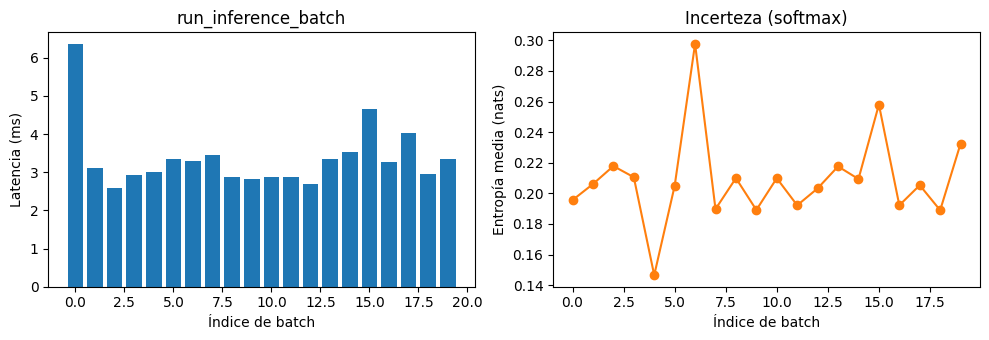

In [12]:
"""Resumen agregado y gráfico de latencias por batch."""

import matplotlib.pyplot as plt

print("latencia ms: media=%.3f std=%.3f" % (df["latency_ms"].mean(), df["latency_ms"].std()))
print("accuracy media (sobre batches visitados): %.4f" % df["acc"].mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(df["batch"], df["latency_ms"], color="C0")
axes[0].set_xlabel("Índice de batch")
axes[0].set_ylabel("Latencia (ms)")
axes[0].set_title("run_inference_batch")

axes[1].plot(df["batch"], df["mean_entropy_nats"], "o-", color="C1")
axes[1].set_xlabel("Índice de batch")
axes[1].set_ylabel("Entropía media (nats)")
axes[1].set_title("Incerteza (softmax)")
fig.tight_layout()
plt.show()

In [ ]:
"""Libera memoria (modelo, loader, tablas) y vacía caché del acelerador."""

import gc

_m = globals().get("model")
_mem_fn = globals().get("model_memory_bytes")
if _m is not None and _mem_fn is not None:
    _pb, _bb, _n = _mem_fn(_m)
    print(
        "Antes de liberar: "
        f"{_n:,} parámetros; {(_pb + _bb) / (1024**2):.2f} MiB "
        f"(pesos {_pb / (1024**2):.2f} MiB + buffers {_bb / (1024**2):.2f} MiB)"
    )

for _name in ("model", "test_loader", "df", "df_samples"):
    if _name in globals():
        del globals()[_name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("Referencias grandes eliminadas; gc y empty_cache del dispositivo.")
